In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# Install necessary libraries (if not already installed)
!pip install h5py matplotlib numpy

# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Specify the root directory containing yearly folders with HDF5 files
root_directory = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5'

# Function to load and visualize data from all HDF5 files in yearly folders
def visualize_all_hdf5_files(root_directory, num_samples=3):
    # Loop through each yearly folder (2018, 2019, 2020, 2021)
    for year in ['2018', '2019', '2020', '2021']:
        year_directory = os.path.join(root_directory, year)
        if not os.path.exists(year_directory):
            print(f"Directory not found: {year_directory}")
            continue

        file_list = [f for f in os.listdir(year_directory) if f.endswith('.hdf5')]

        # Iterate through each HDF5 file in the yearly folder
        for file_name in file_list:
            file_path = os.path.join(year_directory, file_name)
            print(f"Processing file: {file_name} in year {year}")

            # Load the HDF5 file
            with h5py.File(file_path, 'r') as f:
                print("HDF5 file keys:", list(f.keys()))

                # Load a few sample data (adjust the dataset names as per your file structure)
                for i in range(min(num_samples, len(f['input_images']))):
                    input_image = f['input_images'][i]
                    prediction_mask = f['predictions'][i]
                    ground_truth_mask = f['ground_truth'][i]

                    # Generate and save the visualization
                    output_file = f'comparison_{year}_{file_name}_{i}.png'
                    plot_comparison(input_image, prediction_mask, ground_truth_mask, output_file)

# Visualization function
def plot_comparison(image, prediction, ground_truth, output_file='comparison.png'):
    plt.figure(figsize=(12, 4))

    # Input image
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Input Image')
    plt.axis('off')

    # Model prediction
    plt.subplot(1, 3, 2)
    plt.imshow(prediction, cmap='viridis', alpha=0.7)
    plt.title('Model Prediction')
    plt.axis('off')

    # Ground truth
    plt.subplot(1, 3, 3)
    plt.imshow(ground_truth, cmap='viridis', alpha=0.7)
    plt.title('Ground Truth')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()



In [3]:
# Function to inspect the structure of the HDF5 file
def inspect_hdf5_file(file_path):
    with h5py.File(file_path, 'r') as f:
        def print_structure(name, obj):
            print(f"{name}: {type(obj)}")
        f.visititems(print_structure)

# Example usage with the problematic file
inspect_hdf5_file('/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2018/fire_21458798.hdf5')

data: <class 'h5py._hl.dataset.Dataset'>


In [4]:
# Function to examine the contents of the 'data' dataset
def inspect_data_dataset(file_path):
    with h5py.File(file_path, 'r') as f:
        data = f['data']
        print("Data shape:", data.shape)
        print("Data dtype:", data.dtype)
        # Display a sample of the data if possible
        print("Sample data slice:", data[0])

# Example usage with the same file
inspect_data_dataset('/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2018/fire_21458798.hdf5')

Data shape: (14, 23, 304, 247)
Data dtype: float32
Sample data slice: [[[3.2470000e+03 3.2470000e+03 3.2470000e+03 ... 2.7640000e+03
   1.0850000e+03 1.0850000e+03]
  [2.0800000e+03 2.0800000e+03 3.2470000e+03 ... 2.7640000e+03
   2.7640000e+03 1.0850000e+03]
  [2.6270000e+03 2.6270000e+03 2.6270000e+03 ... 1.7690000e+03
   1.3540000e+03 1.3540000e+03]
  ...
  [7.4900000e+02 7.4900000e+02 7.4900000e+02 ... 1.8810000e+03
   1.8810000e+03 1.8810000e+03]
  [6.7200000e+02 6.7200000e+02 1.0490000e+03 ... 1.6680000e+03
   1.6680000e+03 1.8810000e+03]
  [8.3800000e+02 8.3800000e+02 8.3800000e+02 ... 1.5680000e+03
   1.5680000e+03 1.5680000e+03]]

 [[4.8660000e+03 4.8660000e+03 4.5630000e+03 ... 4.1250000e+03
   1.9420000e+03 1.9420000e+03]
  [3.0220000e+03 3.0220000e+03 4.8660000e+03 ... 4.9540000e+03
   4.9540000e+03 2.1890000e+03]
  [3.8210000e+03 3.8210000e+03 4.0940000e+03 ... 3.0510000e+03
   2.3460000e+03 2.3460000e+03]
  ...
  [1.9600000e+03 1.9600000e+03 1.7610000e+03 ... 1.8720000e+0

Data shape: (14, 23, 304, 247)


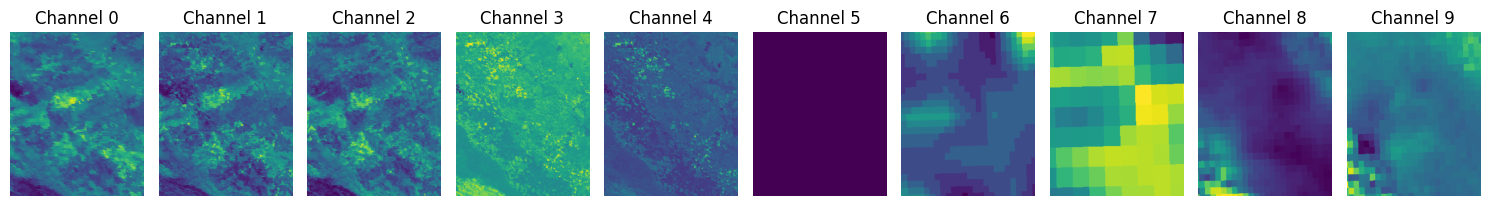

In [5]:
# Function to visualize individual channels of the data
def visualize_data_channels(file_path, time_index=0, num_channels=5):
    with h5py.File(file_path, 'r') as f:
        data = f['data']
        print("Data shape:", data.shape)  # Should be (14, 23, 304, 247)

        # Visualize the first few channels for the given time index
        plt.figure(figsize=(15, 3))
        for i in range(min(num_channels, data.shape[1])):
            plt.subplot(1, num_channels, i + 1)
            plt.imshow(data[time_index, i, :, :], cmap='viridis')
            plt.title(f'Channel {i}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# Example usage with the sample file
visualize_data_channels('/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2018/fire_21458798.hdf5', time_index=0, num_channels=10)

Processing file: fire_21458798.hdf5 in year 2018
Data shape: (14, 23, 304, 247)


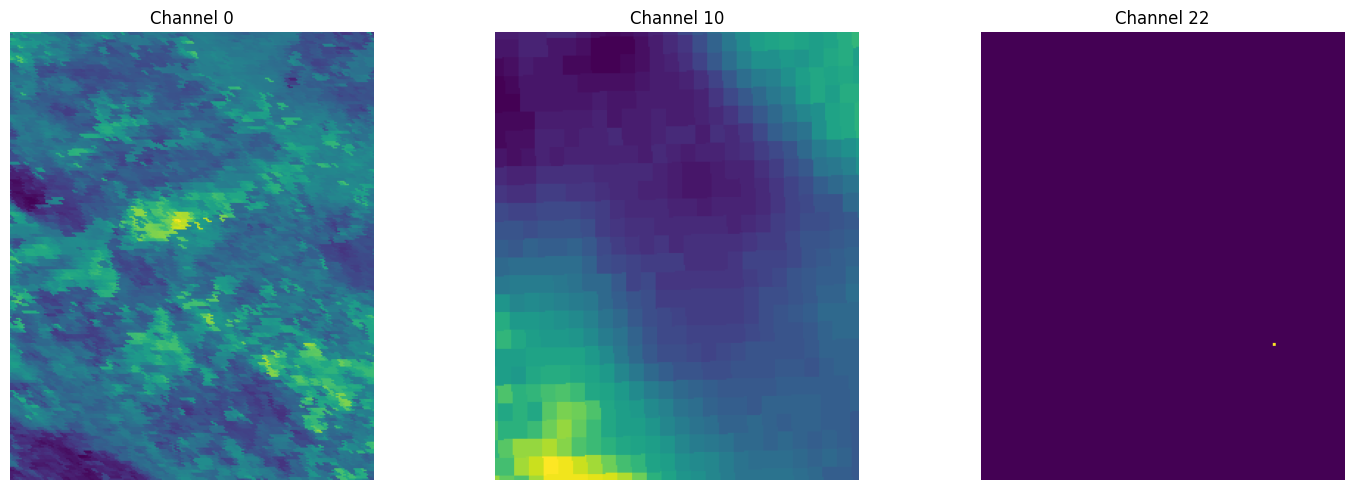

Processing file: fire_22710141.hdf5 in year 2019
Data shape: (19, 23, 308, 233)


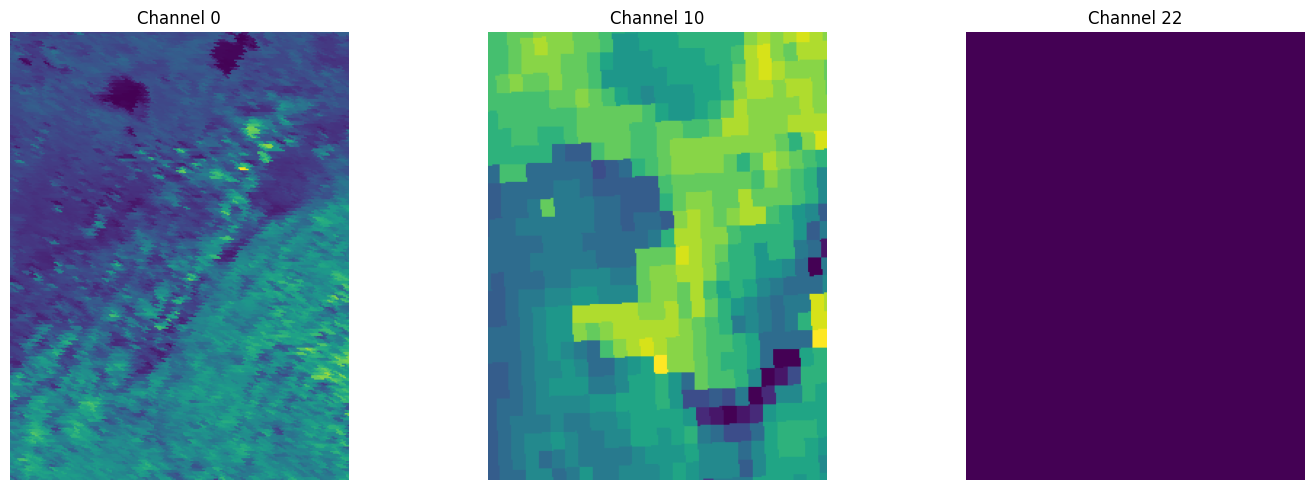

Processing file: fire_23654679.hdf5 in year 2020
Data shape: (28, 23, 336, 293)


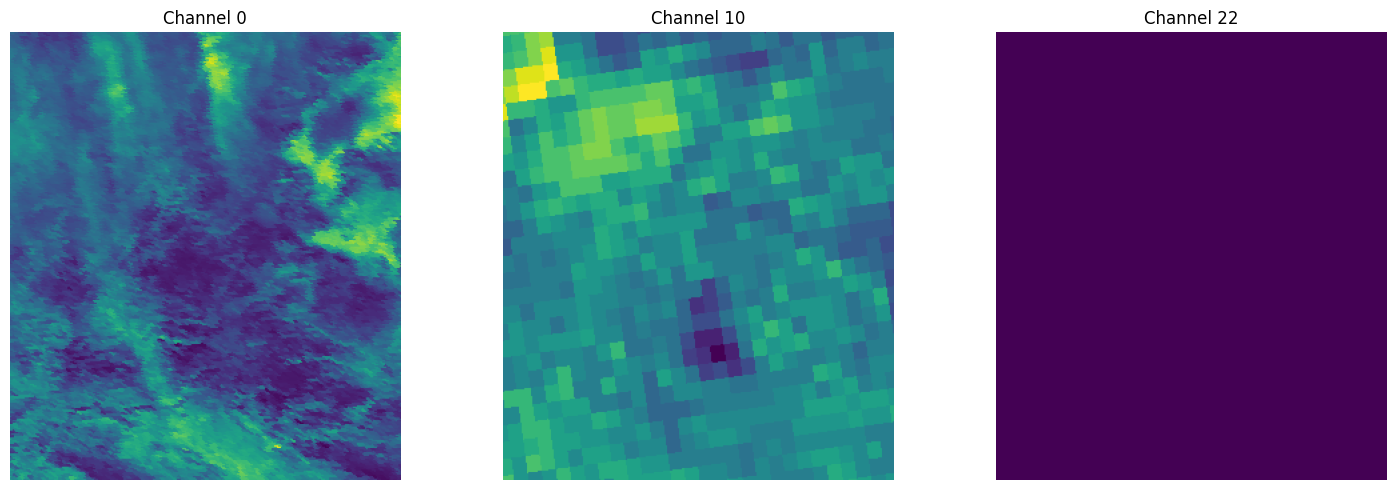

Processing file: fire_24935867.hdf5 in year 2021
Data shape: (27, 23, 304, 245)


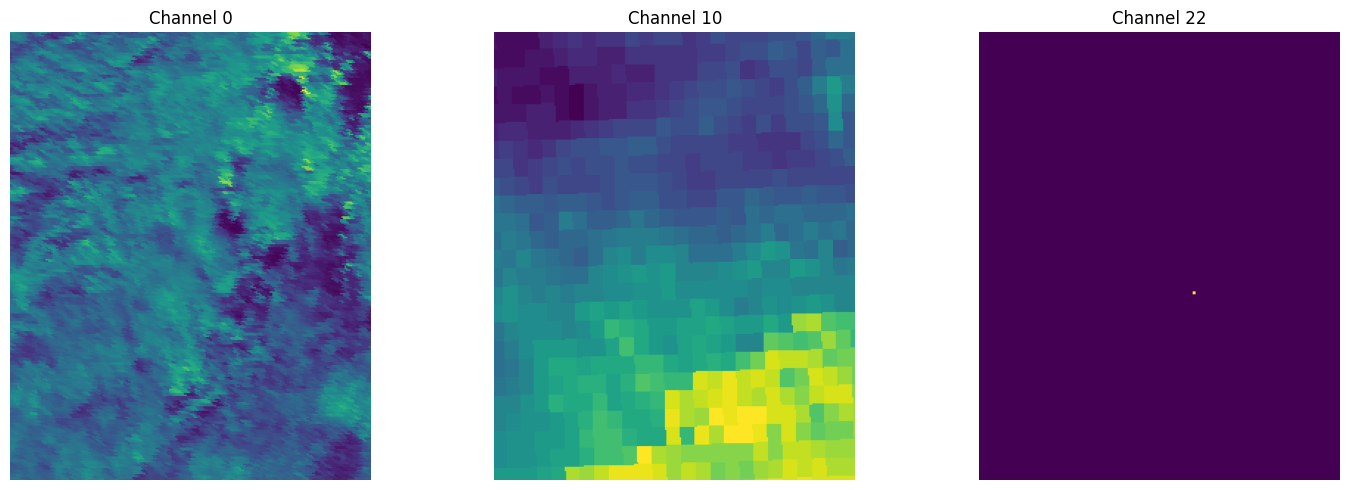

In [6]:
# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Specify the root directory containing yearly folders with HDF5 files
root_directory = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5'

# Function to automatically select and visualize the first available HDF5 file per year
def visualize_first_hdf5_files_per_year(root_directory, channels=[0, 10, 22], time_step=0):
    # Loop through each yearly folder (2018, 2019, 2020, 2021)
    for year in ['2018', '2019', '2020', '2021']:
        year_directory = os.path.join(root_directory, year)
        if not os.path.exists(year_directory):
            print(f"Directory not found: {year_directory}")
            continue

        # Find the first available .hdf5 file in the folder
        file_list = [f for f in os.listdir(year_directory) if f.endswith('.hdf5')]
        if not file_list:
            print(f"No HDF5 files found in directory: {year_directory}")
            continue

        # Use the first file in the list
        file_name = file_list[0]
        file_path = os.path.join(year_directory, file_name)
        print(f"Processing file: {file_name} in year {year}")

        # Load the HDF5 file and visualize relevant channels
        visualize_channels(file_path, time_step=time_step, channels=channels)

# Visualization function for specific channels
def visualize_channels(file_path, time_step=0, channels=[0, 1, 2]):
    try:
        with h5py.File(file_path, 'r') as f:
            data = f['data']
            print("Data shape:", data.shape)  # Should be (14, 23, 304, 247)

            plt.figure(figsize=(15, 5))
            for i, channel in enumerate(channels):
                plt.subplot(1, len(channels), i + 1)
                plt.imshow(data[time_step, channel, :, :], cmap='viridis')
                plt.title(f'Channel {channel}')
                plt.axis('off')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Run the visualization for the first available HDF5 files in yearly folders
visualize_first_hdf5_files_per_year(root_directory, channels=[0, 10, 22], time_step=0)

Visualizing all channels from: /content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2018/fire_21458798.hdf5
Data shape: (14, 23, 304, 247)


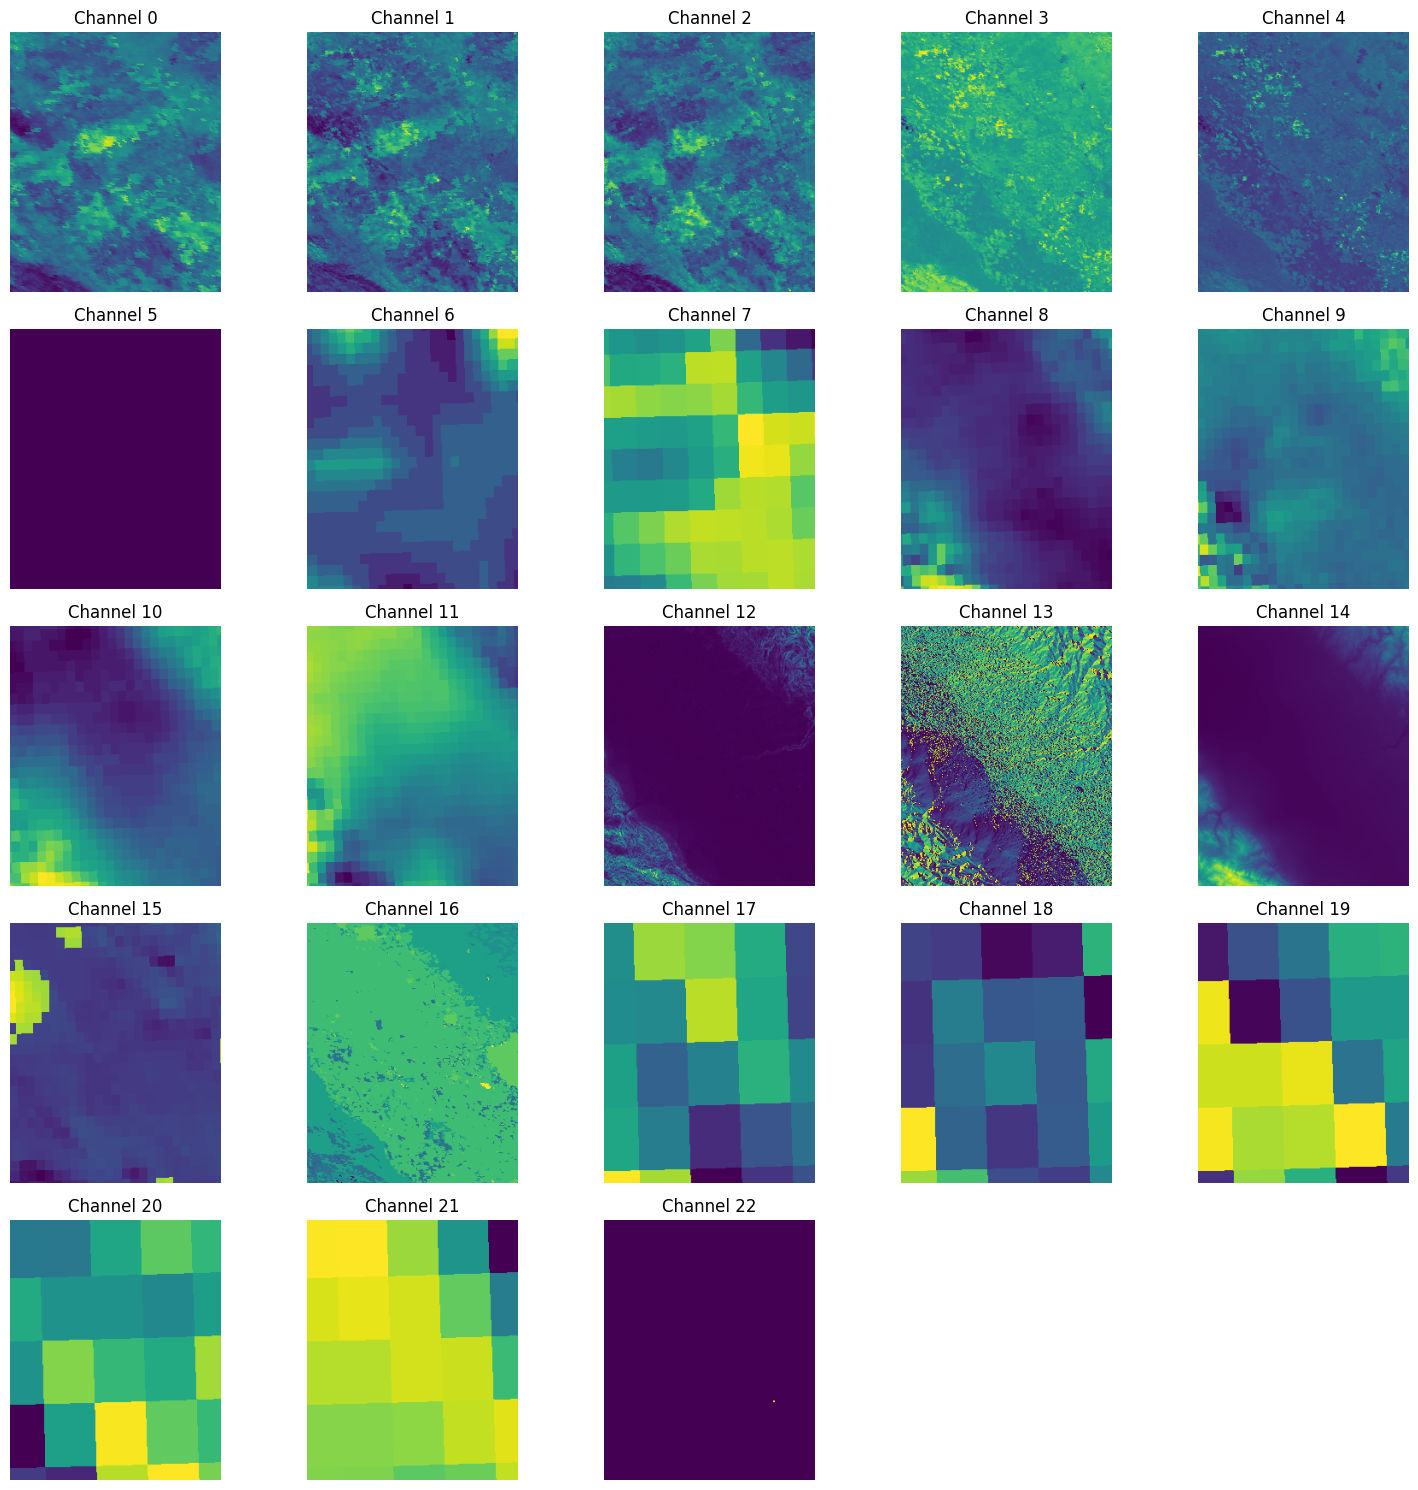

In [7]:
# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Specify the directory containing HDF5 files
root_directory = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5'

# Function to visualize all channels over time
def visualize_all_channels_grid(root_directory, year='2020', file_index=0, time_step=12):
    year_directory = os.path.join(root_directory, year)
    file_list = [f for f in os.listdir(year_directory) if f.endswith('.hdf5')]

    if not file_list:
        print(f"No HDF5 files found in directory: {year_directory}")
        return

    file_path = os.path.join(year_directory, file_list[file_index])
    print(f"Visualizing all channels from: {file_path}")

    with h5py.File(file_path, 'r') as f:
        data = f['data'][:]  # Adjust if your key is different
        print("Data shape:", data.shape)  # Expected: (T, C, H, W)

        num_channels = data.shape[1]
        rows = int(np.ceil(num_channels / 5))  # 5 plots per row

        plt.figure(figsize=(15, 3 * rows))
        for i in range(num_channels):
            plt.subplot(rows, 5, i + 1)
            plt.imshow(data[time_step, i, :, :], cmap='viridis')
            plt.title(f"Channel {i}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Call the function
visualize_all_channels_grid(root_directory, year='2018', file_index=0, time_step=0)

File loaded: /content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2020/fire_24462610.hdf5
Data shape: (36, 23, 297, 219)


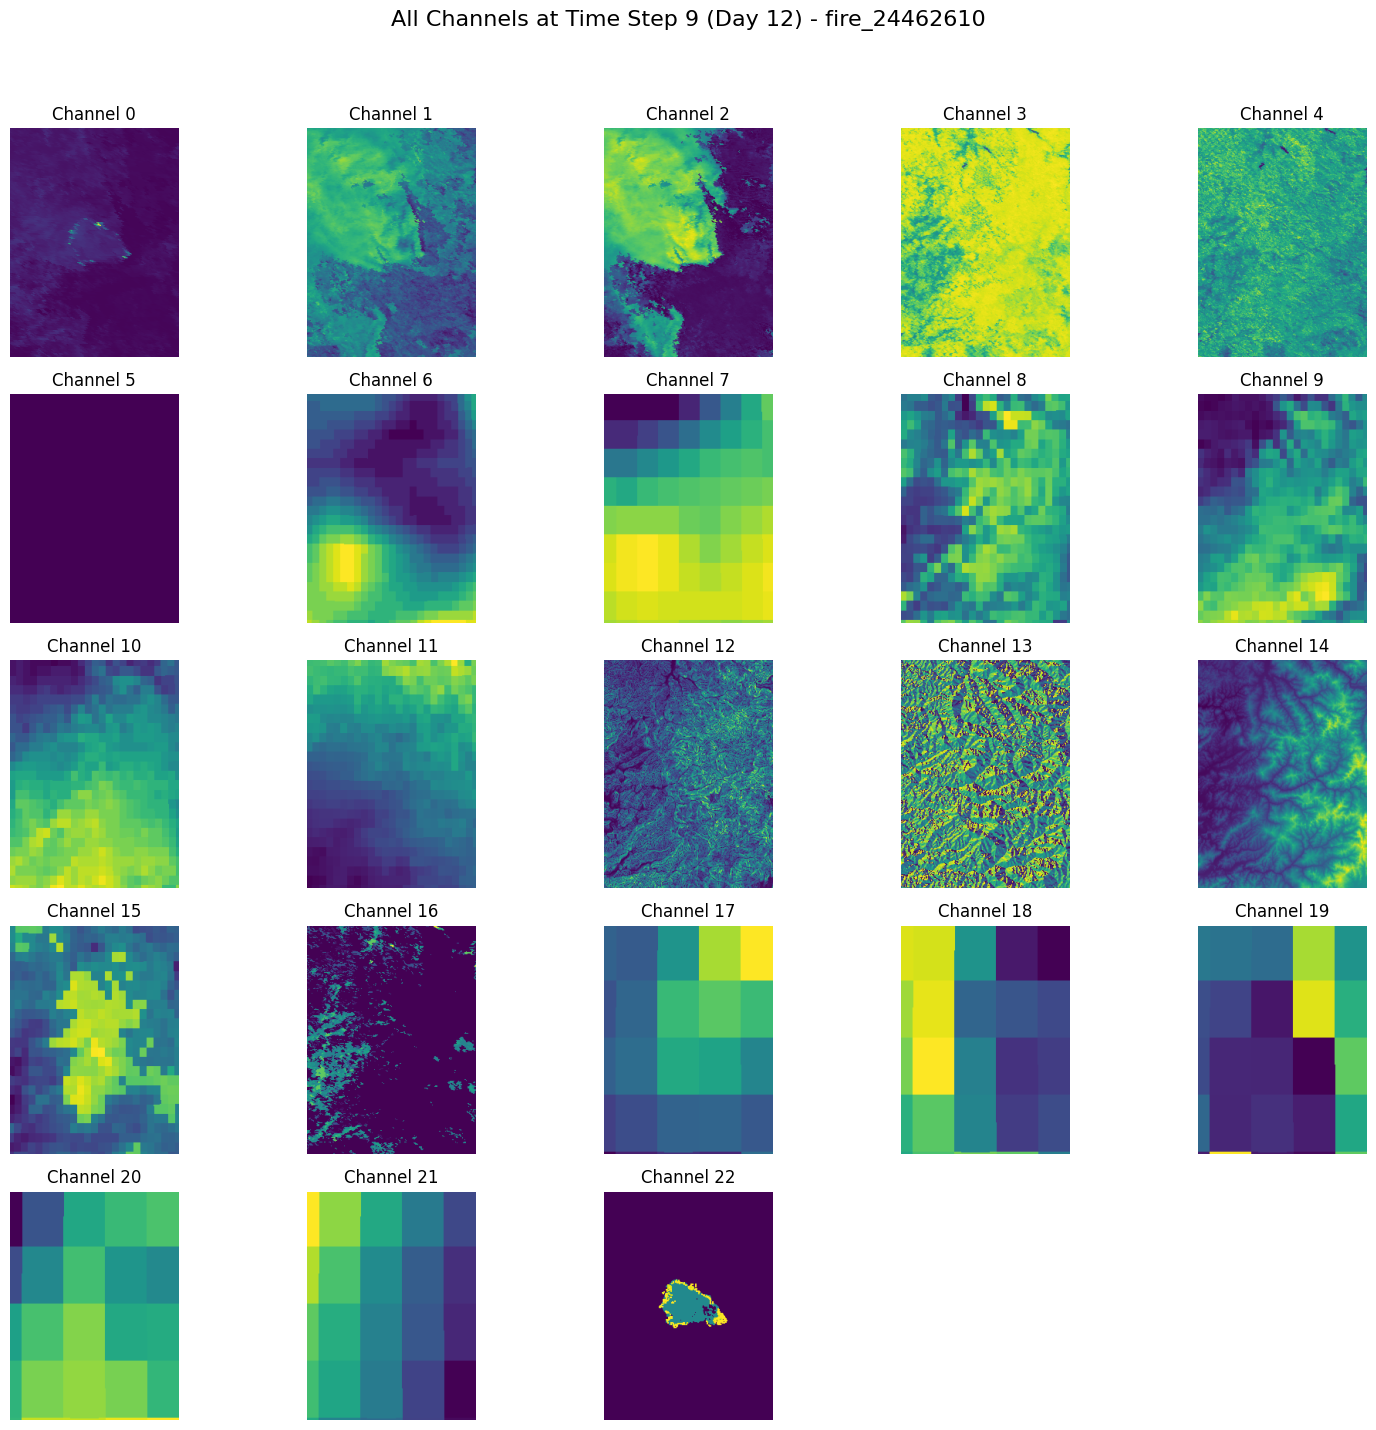

In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Hardcoded path for the specific example
hdf5_path = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2020/fire_24462610.hdf5'
time_step = 10  # Corresponds to Day 12

def visualize_all_channels_for_growth_event(hdf5_path, time_step):
    with h5py.File(hdf5_path, 'r') as f:
        data = f['data'][:]  # Adjust key if needed
        print("File loaded:", hdf5_path)
        print("Data shape:", data.shape)  # Expected: (T, C, H, W)

        num_channels = data.shape[1]
        rows = int(np.ceil(num_channels / 5))  # 5 plots per row

        plt.figure(figsize=(15, 3 * rows))
        for i in range(num_channels):
            plt.subplot(rows, 5, i + 1)
            plt.imshow(data[time_step, i, :, :], cmap='viridis')
            plt.title(f"Channel {i}")
            plt.axis('off')

        plt.suptitle("All Channels at Time Step 9 (Day 12) - fire_24462610", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Call the visualization function
visualize_all_channels_for_growth_event(hdf5_path, time_step)

In [9]:
# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Specify the directory containing HDF5 files
root_directory = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5'

# Target spatial dimensions for resizing
TARGET_HEIGHT, TARGET_WIDTH = 304, 247

# Function to find and display the top n rapid fire growth events with refined criteria
def find_top_n_fire_growth_events(
    root_directory, fire_mask_channel=22, threshold=400, max_files_per_year=100000, top_n=1000
):
    growth_events = []

    for year in ['2018', '2019', '2020', '2021']:
        year_directory = os.path.join(root_directory, year)
        file_list = [f for f in os.listdir(year_directory) if f.endswith('.hdf5')][:max_files_per_year]

        if not file_list:
            continue

        for file_name in file_list:
            file_path = os.path.join(year_directory, file_name)
            print(f"Analyzing file: {file_name} in year {year}")

            with h5py.File(file_path, 'r') as f:
                data = f['data']
                print("Data shape:", data.shape)  # Expected: (T, C, H, W)

                for t in range(data.shape[0] - 1):
                    # Resize fire masks to standard dimensions
                    fire_mask_t = cv2.resize(
                        data[t, fire_mask_channel, :, :], (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST
                    )
                    fire_mask_t1 = cv2.resize(
                        data[t + 1, fire_mask_channel, :, :], (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST
                    )

                    fire_area_t = np.sum(fire_mask_t > 0)
                    fire_area_t1 = np.sum(fire_mask_t1 > 0)
                    growth = fire_area_t1 - fire_area_t

                    # Apply both conditions: growth >= threshold and fire area at least doubles
                    if fire_area_t > 0 and growth >= threshold and fire_area_t1 >= 2 * fire_area_t:
                        growth_events.append({
                            "year": year,
                            "file_name": file_name,
                            "time_step": t,
                            "growth": growth,
                            "before_area": fire_area_t,
                            "after_area": fire_area_t1
                        })

    # Sort events by growth size and select the top n
    growth_events = sorted(growth_events, key=lambda x: x["growth"], reverse=True)[:top_n]

    # Display the top n growth events
    if not growth_events:
        print(f"No fire growth events found with the refined criteria (threshold={threshold}, doubling condition).")
    else:
        print(f"\nTop {top_n} Fire Growth Events:")
        for i, event in enumerate(growth_events):
            print(f"{i+1}. Year: {event['year']}, File: {event['file_name']}, "
                  f"Time Step: {event['time_step']}, Growth: {event['growth']} pixels, "
                  f"Before: {event['before_area']} px, After: {event['after_area']} px")

    return growth_events

In [10]:

import pandas as pd

# Run the function
top_fire_growth_events = find_top_n_fire_growth_events(
    root_directory, threshold=400, max_files_per_year=100000, top_n=1000
)
# Convert to DataFrame and save
df_events = pd.DataFrame(top_fire_growth_events)
csv_path = "/content/drive/MyDrive/Wildfire Spread Prevention Project/top_fire_growth_events.csv"
df_events.to_csv(csv_path, index=False)

print(f"Saved results to {csv_path}")

Analyzing file: fire_21458798.hdf5 in year 2018
Data shape: (14, 23, 304, 247)
Analyzing file: fire_21458801.hdf5 in year 2018
Data shape: (11, 23, 326, 274)
Analyzing file: fire_21458806.hdf5 in year 2018
Data shape: (19, 23, 304, 248)
Analyzing file: fire_21458836.hdf5 in year 2018
Data shape: (35, 23, 307, 254)
Analyzing file: fire_21458848.hdf5 in year 2018
Data shape: (15, 23, 327, 280)
Analyzing file: fire_21459234.hdf5 in year 2018
Data shape: (14, 23, 327, 270)
Analyzing file: fire_21459239.hdf5 in year 2018
Data shape: (15, 23, 324, 270)
Analyzing file: fire_21459242.hdf5 in year 2018
Data shape: (16, 23, 324, 270)
Analyzing file: fire_21459249.hdf5 in year 2018
Data shape: (20, 23, 323, 269)
Analyzing file: fire_21459253.hdf5 in year 2018
Data shape: (15, 23, 340, 295)
Analyzing file: fire_21538827.hdf5 in year 2018
Data shape: (16, 23, 309, 252)
Analyzing file: fire_21615465.hdf5 in year 2018
Data shape: (15, 23, 356, 308)
Analyzing file: fire_21615469.hdf5 in year 2018
Data

In [11]:
# Function to visualize the top n fire growth events using the "viridis" colormap
def visualize_top_fire_growth_events(root_directory, events, fire_mask_channel=22):
    for i, event in enumerate(events):
        file_path = os.path.join(root_directory, event['year'], event['file_name'])

        with h5py.File(file_path, 'r') as f:
            data = f['data']

            plt.figure(figsize=(10, 5))

            # Resize and visualize the "before" fire growth
            before_image = cv2.resize(
                data[event['time_step'], fire_mask_channel, :, :],
                (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST
            )
            plt.subplot(1, 2, 1)
            plt.imshow(before_image, cmap='viridis', interpolation='nearest')
            plt.title(f"Before Growth (Time Step {event['time_step']})")
            plt.axis('off')

            # Resize and visualize the "after" fire growth
            after_image = cv2.resize(
                data[event['time_step'] + 1, fire_mask_channel, :, :],
                (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST
            )
            plt.subplot(1, 2, 2)
            plt.imshow(after_image, cmap='viridis', interpolation='nearest')
            plt.title(f"After Growth (Time Step {event['time_step'] + 1})")
            plt.axis('off')

            plt.suptitle(f"Event {i+1}: {event['growth']} Pixels Growth\nFile: {event['file_name']} | Year: {event['year']}")
            plt.tight_layout()
            plt.show()

# Visualize the top fire growth events with the "viridis" colormap
if top_fire_growth_events:
    visualize_top_fire_growth_events(root_directory, top_fire_growth_events)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import pandas as pd

# Directory to save images
image_save_dir = "/content/drive/MyDrive/Wildfire Spread Prevention Project/results/fire_growth_images"
os.makedirs(image_save_dir, exist_ok=True)  # Ensure the directory exists

# Function to visualize and save images of the top fire growth events
def visualize_and_save_fire_growth_events(root_directory, events, fire_mask_channel=22):
    for i, event in enumerate(events):
        file_path = os.path.join(root_directory, event['year'], event['file_name'])

        with h5py.File(file_path, 'r') as f:
            data = f['data']

            # Create a figure for visualization
            plt.figure(figsize=(10, 5))

            # Resize and visualize the "before" fire growth
            before_image = cv2.resize(
                data[event['time_step'], fire_mask_channel, :, :],
                (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST
            )
            plt.subplot(1, 2, 1)
            plt.imshow(before_image, cmap='viridis', interpolation='nearest')
            plt.title(f"Before Growth (Time Step {event['time_step']})")
            plt.axis('off')

            # Resize and visualize the "after" fire growth
            after_image = cv2.resize(
                data[event['time_step'] + 1, fire_mask_channel, :, :],
                (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST
            )
            plt.subplot(1, 2, 2)
            plt.imshow(after_image, cmap='viridis', interpolation='nearest')
            plt.title(f"After Growth (Time Step {event['time_step'] + 1})")
            plt.axis('off')

            plt.suptitle(f"Event {i+1}: {event['growth']} Pixels Growth\nFile: {event['file_name']} | Year: {event['year']}")
            plt.tight_layout()

            # Save the figure as an image
            image_filename = f"{event['year']}_{event['file_name'].replace('.hdf5', '')}_T{event['time_step']}.png"
            image_path = os.path.join(image_save_dir, image_filename)
            plt.savefig(image_path, bbox_inches='tight')
            plt.close()

            # Add image path to event dictionary
            event["image_path"] = image_path

# Run visualization and save images
visualize_and_save_fire_growth_events(root_directory, top_fire_growth_events)

# Convert to DataFrame and save CSV with image paths
df_events = pd.DataFrame(top_fire_growth_events)
csv_path = "/content/drive/MyDrive/Wildfire Spread Prevention Project/results/top_fire_growth_events_with_images.csv"
df_events.to_csv(csv_path, index=False)

print(f"Saved results and images. CSV path: {csv_path}")

Saved results and images. CSV path: /content/drive/MyDrive/Wildfire Spread Prevention Project/results/top_fire_growth_events_with_images.csv


Visualizing all 23 channels for File: fire_24332700.hdf5 at Time Step: 9


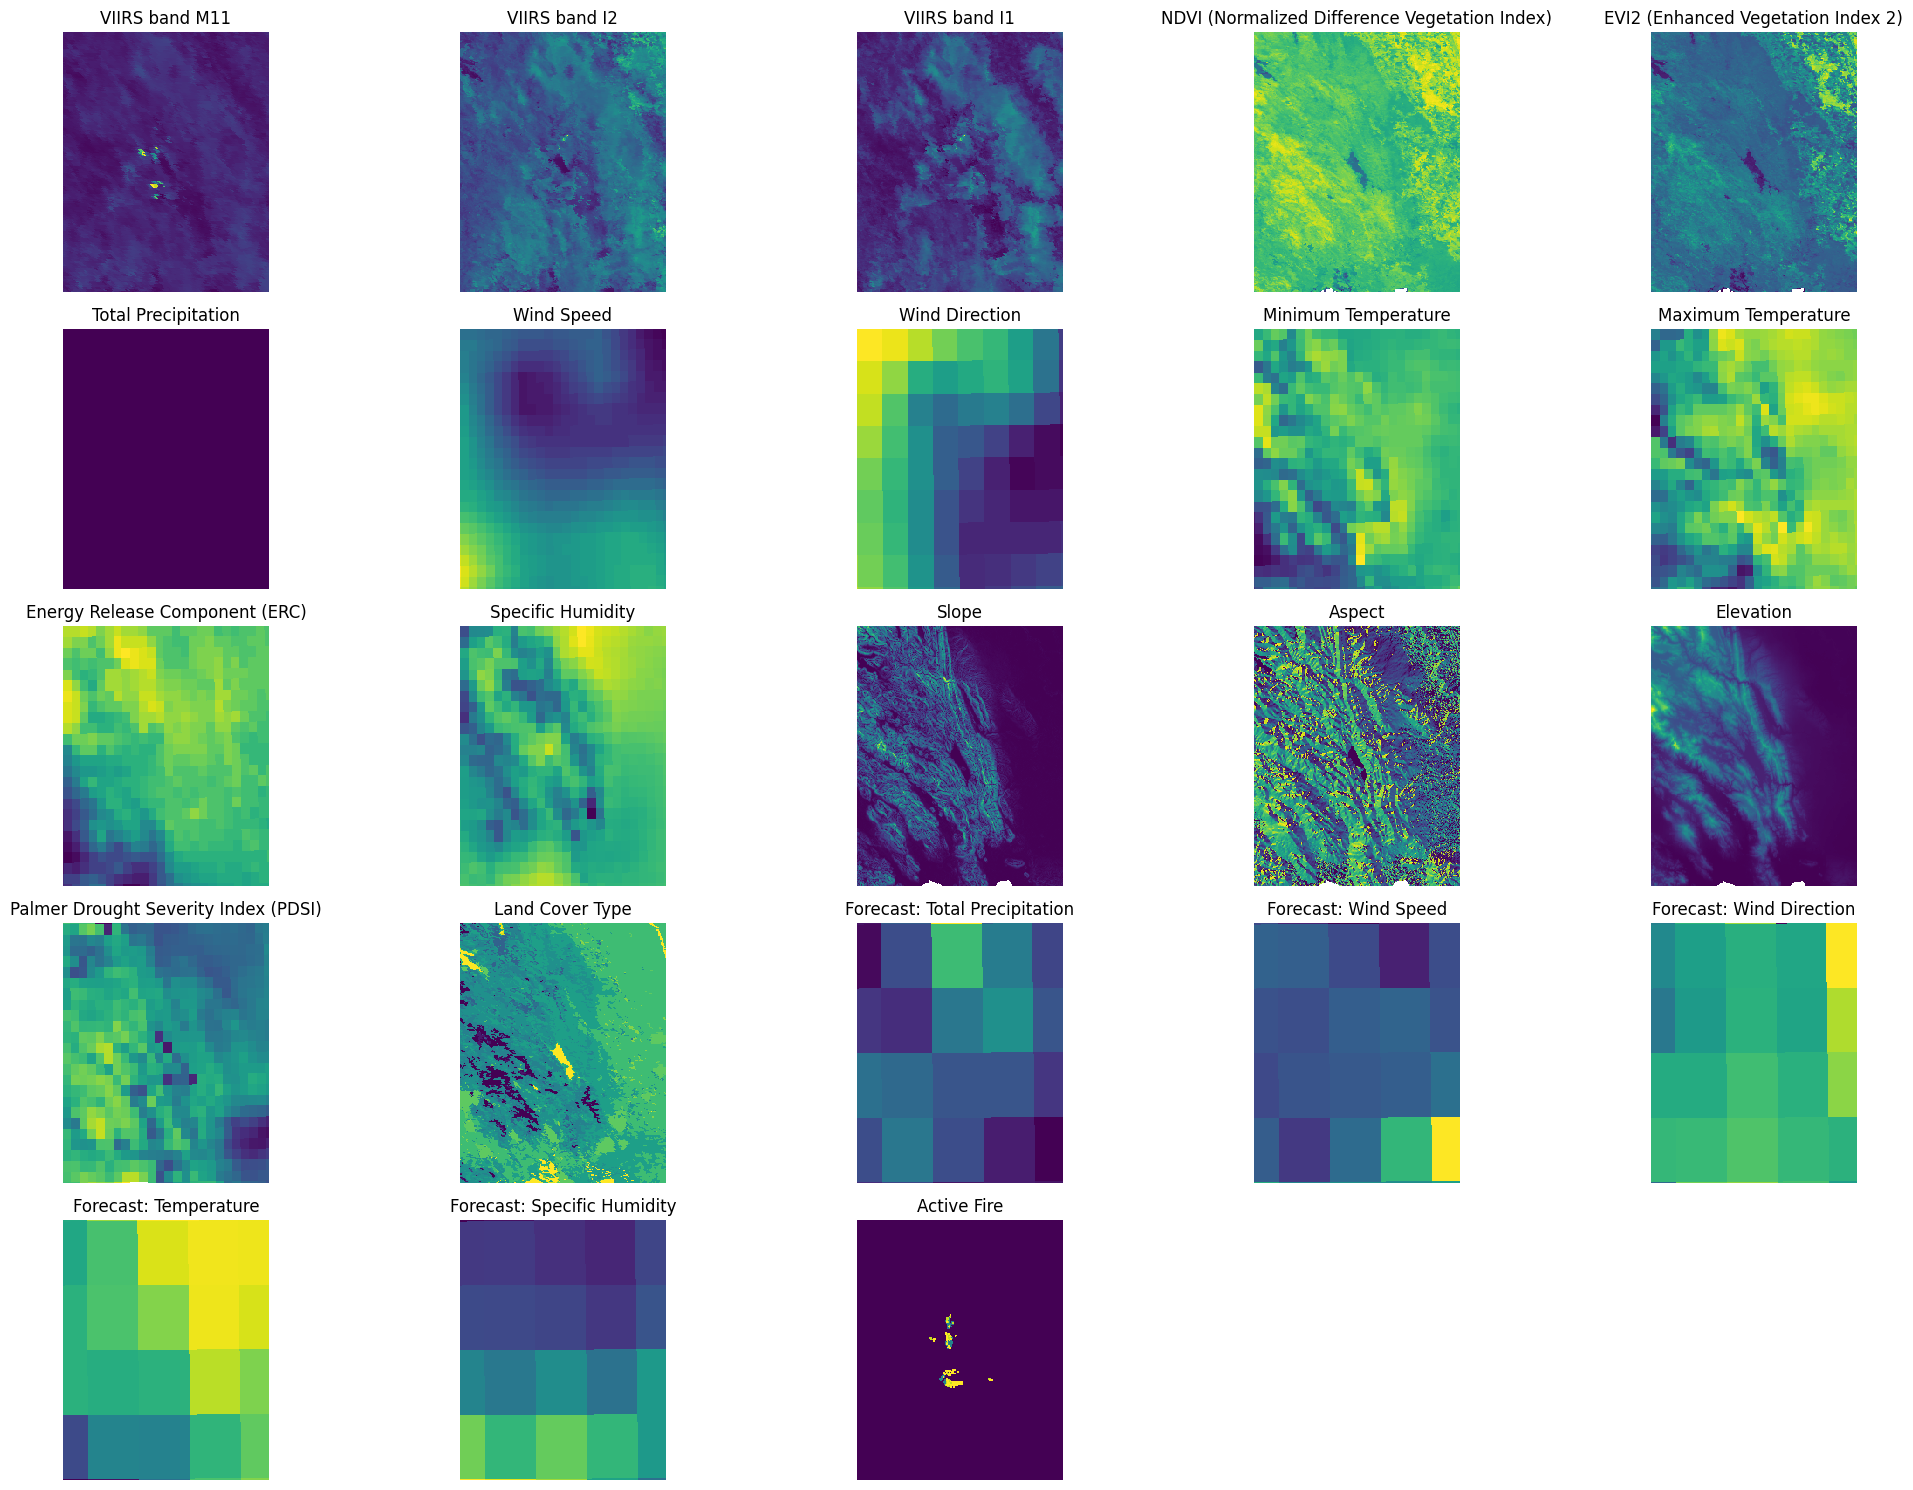

In [ ]:
# Define correct channel descriptions based on the WildfireSpreadTS documentation
channel_labels = [
    "VIIRS band M11", "VIIRS band I2", "VIIRS band I1",
    "NDVI (Normalized Difference Vegetation Index)", "EVI2 (Enhanced Vegetation Index 2)",
    "Total Precipitation", "Wind Speed", "Wind Direction",
    "Minimum Temperature", "Maximum Temperature", "Energy Release Component (ERC)",
    "Specific Humidity", "Slope", "Aspect", "Elevation",
    "Palmer Drought Severity Index (PDSI)", "Land Cover Type",
    "Forecast: Total Precipitation", "Forecast: Wind Speed",
    "Forecast: Wind Direction", "Forecast: Temperature",
    "Forecast: Specific Humidity", "Active Fire"
]

# Function to visualize all channels with correct labels
def visualize_all_channels_with_correct_labels(
    root_directory, year='2020', file_name='fire_24332700.hdf5', time_step=9, cmap='viridis'
):
    file_path = os.path.join(root_directory, year, file_name)

    with h5py.File(file_path, 'r') as f:
        data = f['data']
        num_channels = data.shape[1]
        print(f"Visualizing all {num_channels} channels for File: {file_name} at Time Step: {time_step}")

        plt.figure(figsize=(20, 15))

        for channel_index in range(num_channels):
            plt.subplot(5, 5, channel_index + 1)
            plt.imshow(data[time_step, channel_index, :, :], cmap=cmap, interpolation='nearest')
            plt.title(f"{channel_labels[channel_index]}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Visualize all channels for the fire growth event with the updated channel labels
visualize_all_channels_with_correct_labels(
    root_directory, year='2020', file_name='fire_24332700.hdf5', time_step=9, cmap='viridis'
)

Visualizing all 23 channels for File: fire_25294714.hdf5 at Time Step: 27


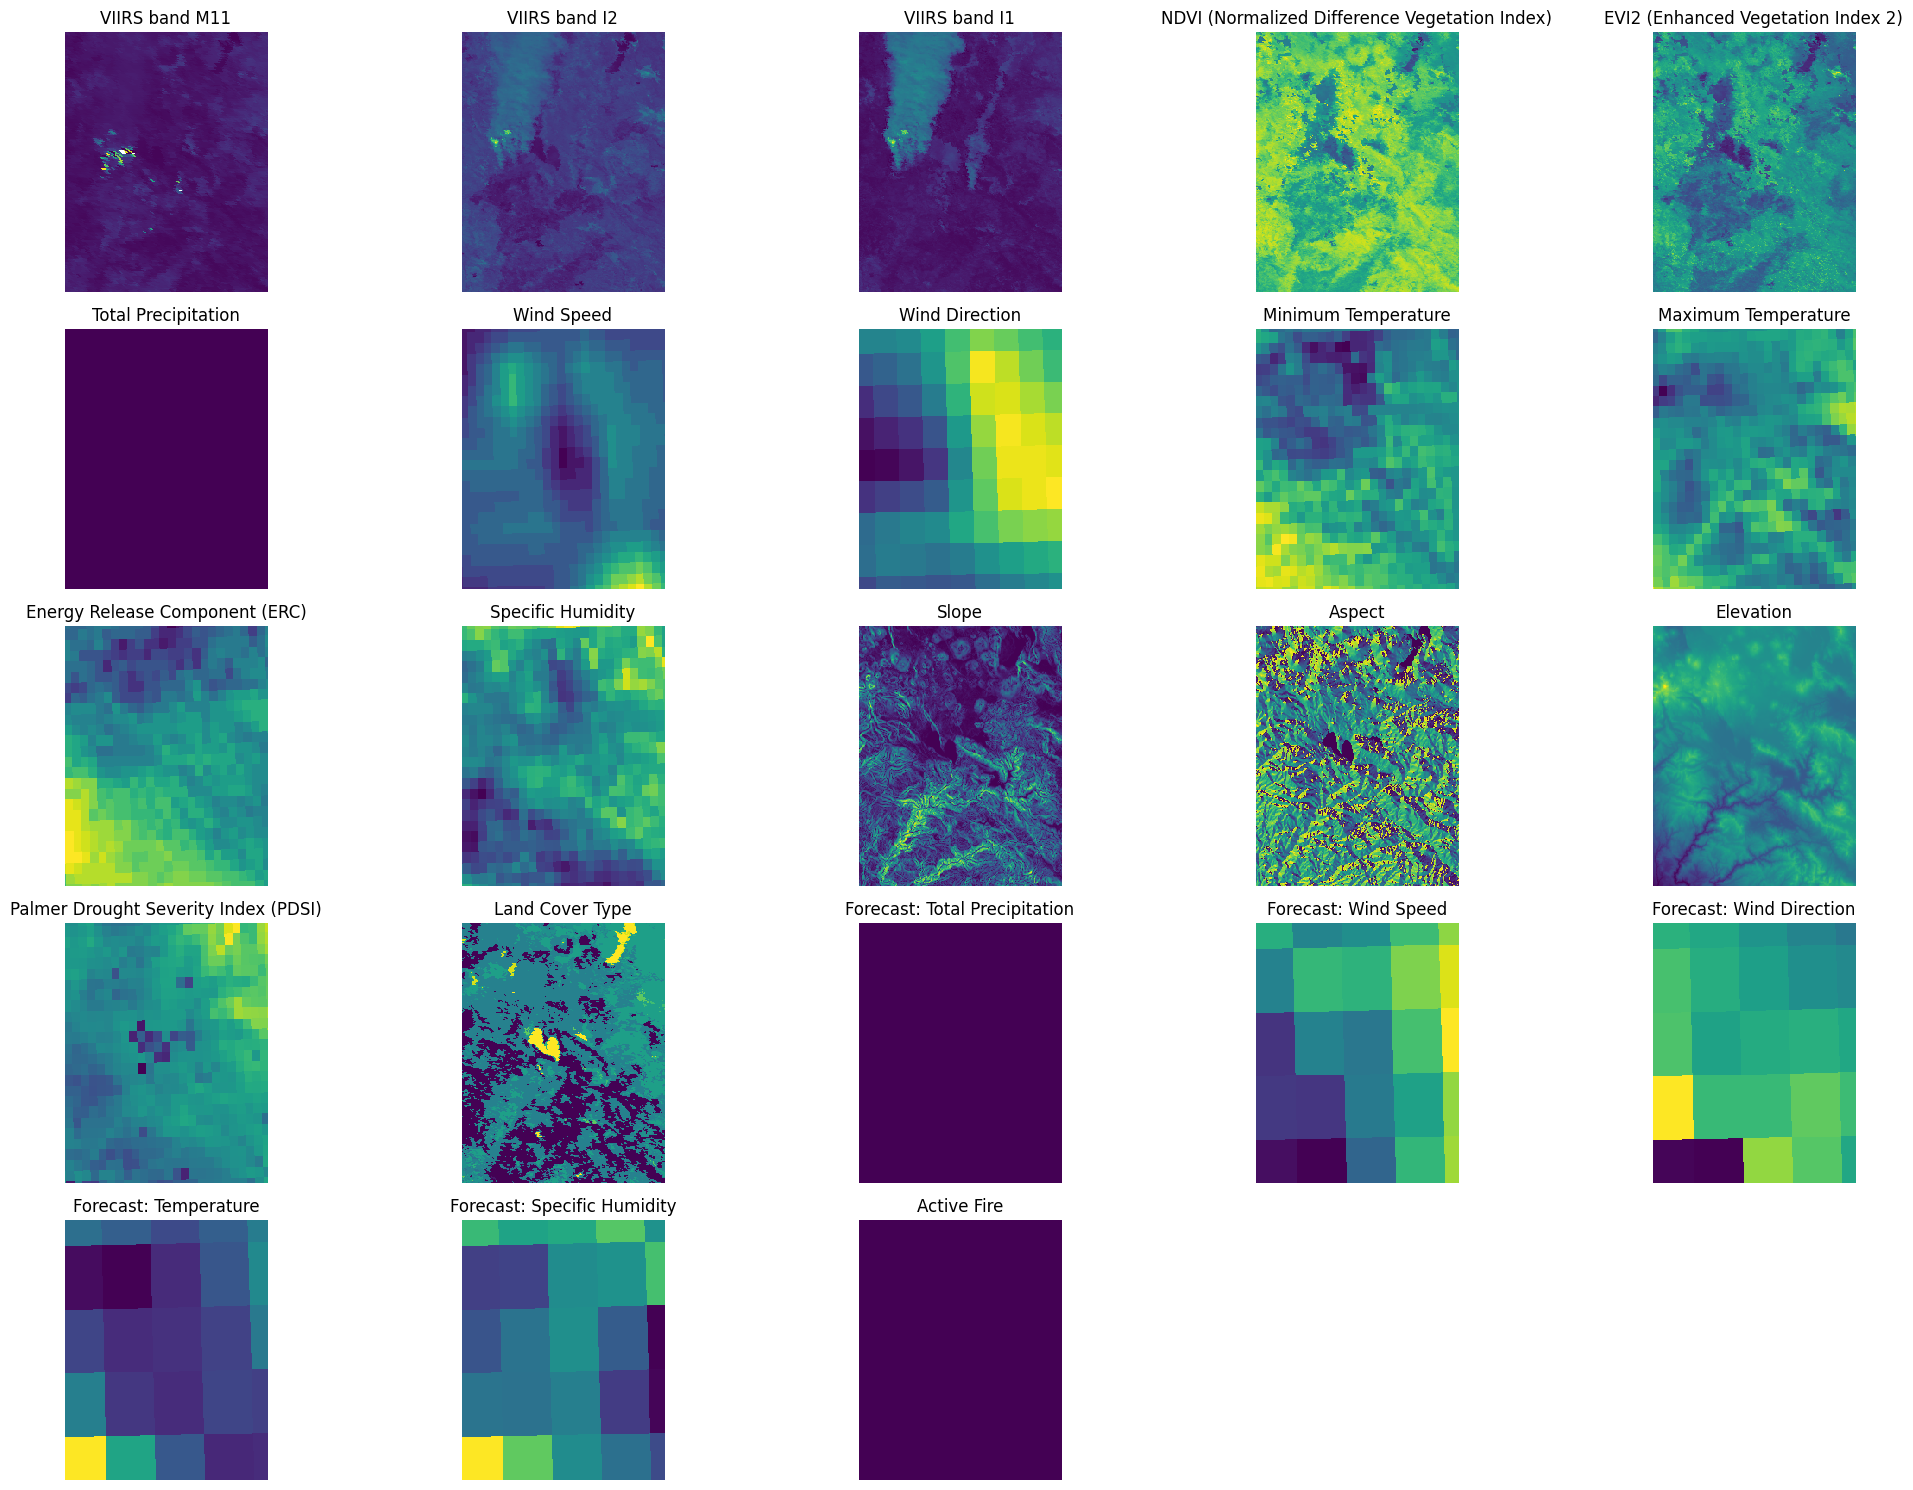

In [ ]:
# Function to visualize all channels with correct labels for the first fire growth event
def visualize_all_channels_for_fire_1(
    root_directory, year='2021', file_name='fire_25294714.hdf5', time_step=27, cmap='viridis'
):
    file_path = os.path.join(root_directory, year, file_name)

    with h5py.File(file_path, 'r') as f:
        data = f['data']
        num_channels = data.shape[1]
        print(f"Visualizing all {num_channels} channels for File: {file_name} at Time Step: {time_step}")

        plt.figure(figsize=(20, 15))

        for channel_index in range(num_channels):
            plt.subplot(5, 5, channel_index + 1)
            plt.imshow(data[time_step, channel_index, :, :], cmap=cmap, interpolation='nearest')
            plt.title(f"{channel_labels[channel_index]}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

# Visualize all channels for the first fire growth event with the updated channel labels
visualize_all_channels_for_fire_1(
    root_directory, year='2021', file_name='fire_25294714.hdf5', time_step=27, cmap='viridis'
)

Processing Event 1: File: fire_25294714.hdf5, Year: 2021, Time Step: 27

Top 5 Channels with Most Change for Event 1:
VIIRS band M11: Magnitude=nan, Mean=nan, Std=nan
VIIRS band I1: Magnitude=79659032.0, Mean=482.52, Std=1696.88
VIIRS band I2: Magnitude=58372388.0, Mean=421.23, Std=1278.79
NDVI (Normalized Difference Vegetation Index): Magnitude=57564220.0, Mean=-417.78, Std=1472.81
EVI2 (Enhanced Vegetation Index 2): Magnitude=29843434.0, Mean=-243.38, Std=716.43
Error processing /content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5/2021/fire_25294714.hdf5: 'growth'
Processing Event 2: File: fire_24332700.hdf5, Year: 2020, Time Step: 9

Top 5 Channels with Most Change for Event 2:
VIIRS band I1: Magnitude=50529528.0, Mean=235.95, Std=920.44
VIIRS band I2: Magnitude=41406940.0, Mean=83.56, Std=737.85
VIIRS band M11: Magnitude=40662900.0, Mean=268.59, Std=1041.03
NDVI (Normalized Difference Vegetation Index): Magnitude=nan, Mean=nan, Std=nan
EVI2 (Enhanced Vege

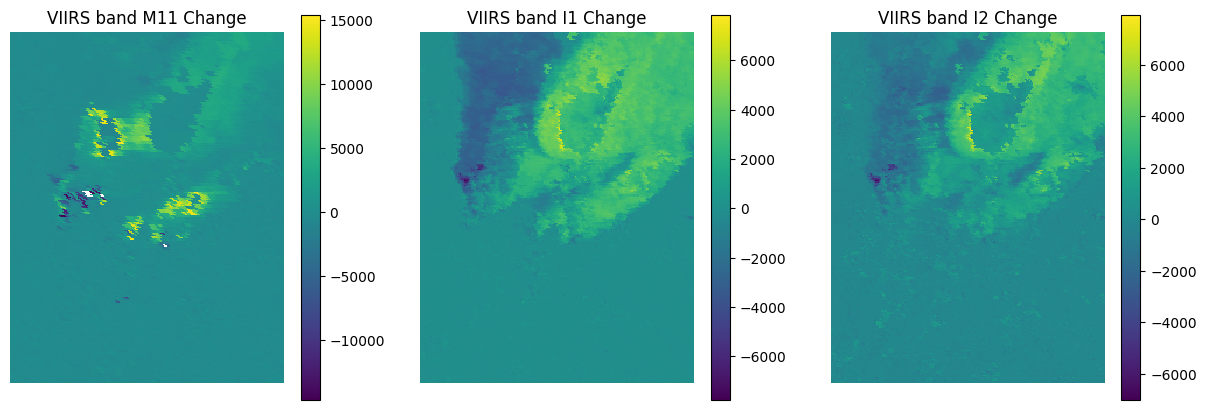

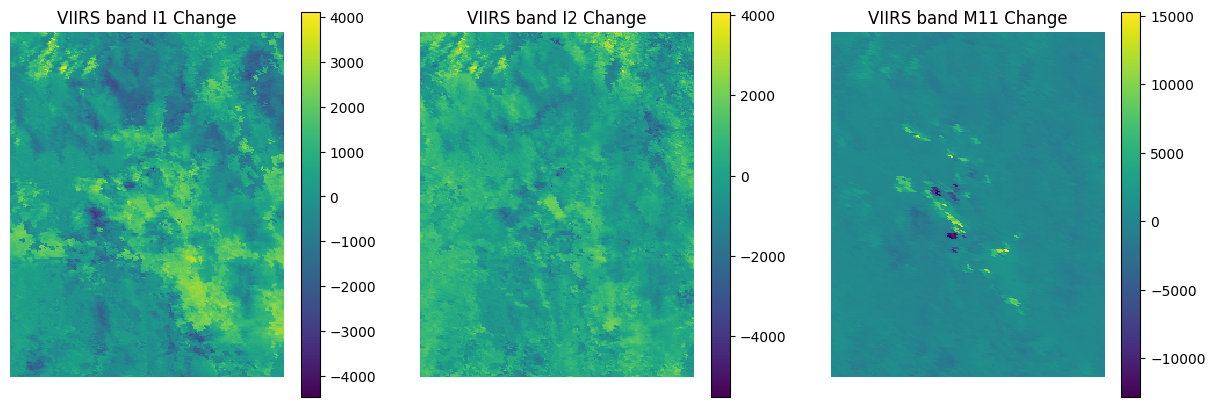

In [ ]:
# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

# Function to analyze and visualize key differences for rapid fire growth events
def analyze_fire_growth_events_efficiently(
    root_directory, events, fire_mask_channel=22, cmap='viridis'
):
    for i, event in enumerate(events):
        file_path = os.path.join(root_directory, event['year'], event['file_name'])
        print(f"Processing Event {i+1}: File: {event['file_name']}, Year: {event['year']}, Time Step: {event['time_step']}")

        try:
            with h5py.File(file_path, 'r') as f:
                data = f['data']

                # Get fire mask before and after fire growth
                fire_mask_before = data[event['time_step'], fire_mask_channel, :, :]
                fire_mask_after = data[event['time_step'] + 1, fire_mask_channel, :, :]

                fire_growth = (fire_mask_after > 0).astype(int) - (fire_mask_before > 0).astype(int)

                # Efficiently analyze all channels
                channel_changes = {}
                for channel_index in range(data.shape[1]):
                    channel_data_before = data[event['time_step'], channel_index, :, :]
                    channel_data_after = data[event['time_step'] + 1, channel_index, :, :]
                    channel_diff = channel_data_after - channel_data_before

                    # Compute statistics for the channel change
                    change_magnitude = np.sum(np.abs(channel_diff))
                    change_mean = np.mean(channel_diff)
                    change_std = np.std(channel_diff)

                    channel_changes[channel_labels[channel_index]] = {
                        "magnitude": change_magnitude,
                        "mean": change_mean,
                        "std": change_std
                    }

                # Sort channels by the magnitude of changes
                sorted_channels = sorted(channel_changes.items(), key=lambda x: x[1]["magnitude"], reverse=True)

                # Display top 5 changing channels
                print(f"\nTop 5 Channels with Most Change for Event {i+1}:")
                for channel_name, stats in sorted_channels[:5]:
                    print(f"{channel_name}: Magnitude={stats['magnitude']}, Mean={stats['mean']:.2f}, Std={stats['std']:.2f}")

                # Visualization of top 3 changing channels
                plt.figure(figsize=(15, 5))
                for idx, (channel_name, stats) in enumerate(sorted_channels[:3]):
                    channel_index = channel_labels.index(channel_name)
                    channel_data_before = data[event['time_step'], channel_index, :, :]
                    channel_data_after = data[event['time_step'] + 1, channel_index, :, :]
                    channel_diff = channel_data_after - channel_data_before

                    plt.subplot(1, 3, idx + 1)
                    plt.imshow(channel_diff, cmap=cmap, interpolation='nearest')
                    plt.title(f"{channel_name} Change")
                    plt.colorbar()
                    plt.axis('off')

                plt.suptitle(f"Event {i+1}: {event['growth']} Pixels Growth\nFile: {event['file_name']} | Year: {event['year']}")
                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

# Run the updated analysis for the top two fire growth events
analyze_fire_growth_events_efficiently(
    root_directory,
    events=[
        {"year": '2021', "file_name": 'fire_25294714.hdf5', "time_step": 27},
        {"year": '2020', "file_name": 'fire_24332700.hdf5', "time_step": 9}
    ]
)

In [ ]:
# Function to list the total number of time steps for each HDF5 fire file
def list_time_steps_per_fire(root_directory):
    time_steps_per_fire = {}

    for year in ['2018', '2019', '2020', '2021']:
        year_directory = os.path.join(root_directory, year)
        file_list = [f for f in os.listdir(year_directory) if f.endswith('.hdf5')]

        for file_name in file_list:
            file_path = os.path.join(year_directory, file_name)

            try:
                with h5py.File(file_path, 'r') as f:
                    data = f['data']
                    num_time_steps = data.shape[0]
                    time_steps_per_fire[file_name] = num_time_steps
                    print(f"File: {file_name}, Year: {year}, Time Steps: {num_time_steps}")

            except Exception as e:
                print(f"Error reading {file_path}: {e}")

    return time_steps_per_fire

# Run the code to get the number of time steps for each fire
time_steps_per_fire = list_time_steps_per_fire(root_directory)

File: fire_21458798.hdf5, Year: 2018, Time Steps: 14
File: fire_21458801.hdf5, Year: 2018, Time Steps: 11
File: fire_21458806.hdf5, Year: 2018, Time Steps: 19
File: fire_21458836.hdf5, Year: 2018, Time Steps: 35
File: fire_21458848.hdf5, Year: 2018, Time Steps: 15
File: fire_21459234.hdf5, Year: 2018, Time Steps: 14
File: fire_21459239.hdf5, Year: 2018, Time Steps: 15
File: fire_21459242.hdf5, Year: 2018, Time Steps: 16
File: fire_21459249.hdf5, Year: 2018, Time Steps: 20
File: fire_21459253.hdf5, Year: 2018, Time Steps: 15
File: fire_21538827.hdf5, Year: 2018, Time Steps: 16
File: fire_21615465.hdf5, Year: 2018, Time Steps: 15
File: fire_21615469.hdf5, Year: 2018, Time Steps: 11
File: fire_21617464.hdf5, Year: 2018, Time Steps: 12
File: fire_21688910.hdf5, Year: 2018, Time Steps: 19
File: fire_21688916.hdf5, Year: 2018, Time Steps: 33
File: fire_21690064.hdf5, Year: 2018, Time Steps: 38
File: fire_21690071.hdf5, Year: 2018, Time Steps: 17
File: fire_21690073.hdf5, Year: 2018, Time Ste

KeyboardInterrupt: 

Processing Event: File: fire_25294714.hdf5, Year: 2021, Time Step: 27
Processing Event: File: fire_24332700.hdf5, Year: 2020, Time Step: 9
Processing Event: File: fire_24332628.hdf5, Year: 2020, Time Step: 28


/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processing Event: File: fire_24332647.hdf5, Year: 2020, Time Step: 28
Processing Event: File: fire_24332628.hdf5, Year: 2020, Time Step: 8


<ipython-input-11-6e5d9df6900a>:38: RuntimeWarning: Mean of empty slice
  avg_correlations = {k: np.nanmean(v) for k, v in correlations.items()}


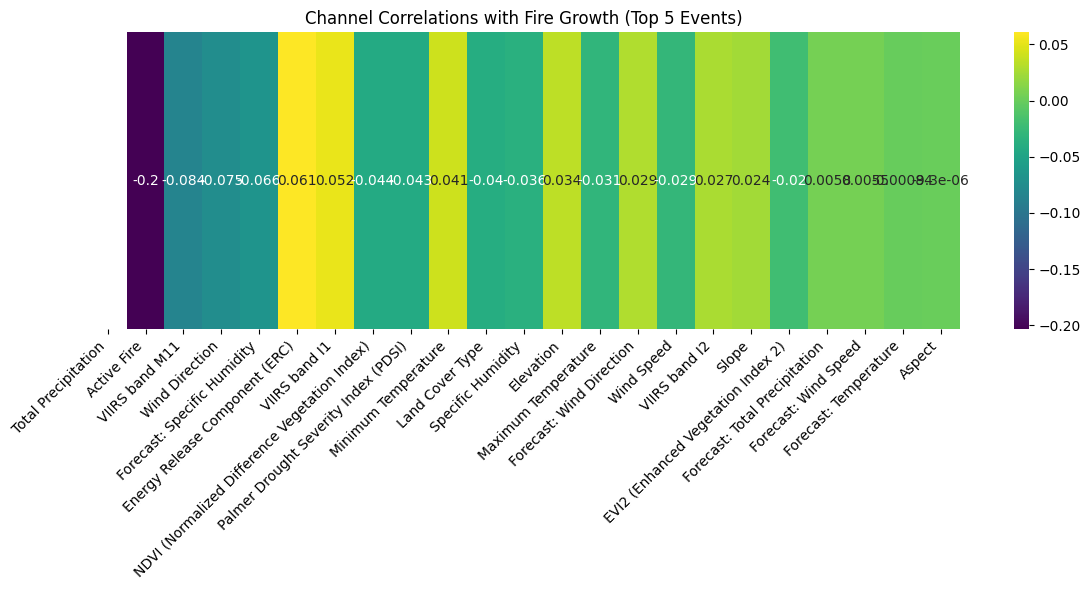

In [ ]:
# Import required libraries
import seaborn as sns
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Function to calculate and visualize channel correlations with fire growth
def visualize_channel_correlations(
    root_directory, events, fire_mask_channel=22, cmap='viridis'
):
    correlations = {}

    for event in events:
        file_path = os.path.join(root_directory, event['year'], event['file_name'])
        print(f"Processing Event: File: {event['file_name']}, Year: {event['year']}, Time Step: {event['time_step']}")

        with h5py.File(file_path, 'r') as f:
            data = f['data']

            # Calculate fire growth as the difference between time steps
            before_fire = data[event['time_step'], fire_mask_channel, :, :]
            after_fire = data[event['time_step'] + 1, fire_mask_channel, :, :]
            fire_growth = (after_fire > 0).astype(int) - (before_fire > 0).astype(int)

            # Calculate correlation of each channel with fire growth
            for channel_index in range(data.shape[1]):
                channel_data = data[event['time_step'], channel_index, :, :].flatten()
                if not np.isnan(channel_data).any():
                    correlation = np.corrcoef(channel_data, fire_growth.flatten())[0, 1]
                    channel_name = channel_labels[channel_index]

                    if channel_name not in correlations:
                        correlations[channel_name] = []

                    correlations[channel_name].append(correlation)

    # Aggregate correlations and visualize as a heatmap
    avg_correlations = {k: np.nanmean(v) for k, v in correlations.items()}
    sorted_correlations = dict(sorted(avg_correlations.items(), key=lambda item: abs(item[1]), reverse=True))

    plt.figure(figsize=(12, 6))
    sns.heatmap([list(sorted_correlations.values())], annot=True, cmap=cmap, xticklabels=list(sorted_correlations.keys()))
    plt.title('Channel Correlations with Fire Growth (Top 5 Events)')
    plt.yticks([], [])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Run correlation visualization for all 5 largest fire growth events
visualize_channel_correlations(
    root_directory,
    events=[
        {"year": '2021', "file_name": 'fire_25294714.hdf5', "time_step": 27},
        {"year": '2020', "file_name": 'fire_24332700.hdf5', "time_step": 9},
        {"year": '2020', "file_name": 'fire_24332628.hdf5', "time_step": 28},
        {"year": '2020', "file_name": 'fire_24332647.hdf5', "time_step": 28},
        {"year": '2020', "file_name": 'fire_24332628.hdf5', "time_step": 8}
    ]
)

Processing Event: File: fire_25294714.hdf5, Year: 2021, Time Step: 27
Processing Event: File: fire_24332700.hdf5, Year: 2020, Time Step: 9
Processing Event: File: fire_24332628.hdf5, Year: 2020, Time Step: 28
Processing Event: File: fire_24332647.hdf5, Year: 2020, Time Step: 28
Processing Event: File: fire_24332628.hdf5, Year: 2020, Time Step: 8


<ipython-input-14-509ce013e8bf>:32: RuntimeWarning: Mean of empty slice
  avg_correlations = {k: np.nanmean(v) for k, v in correlations.items() if len(v) > 0}


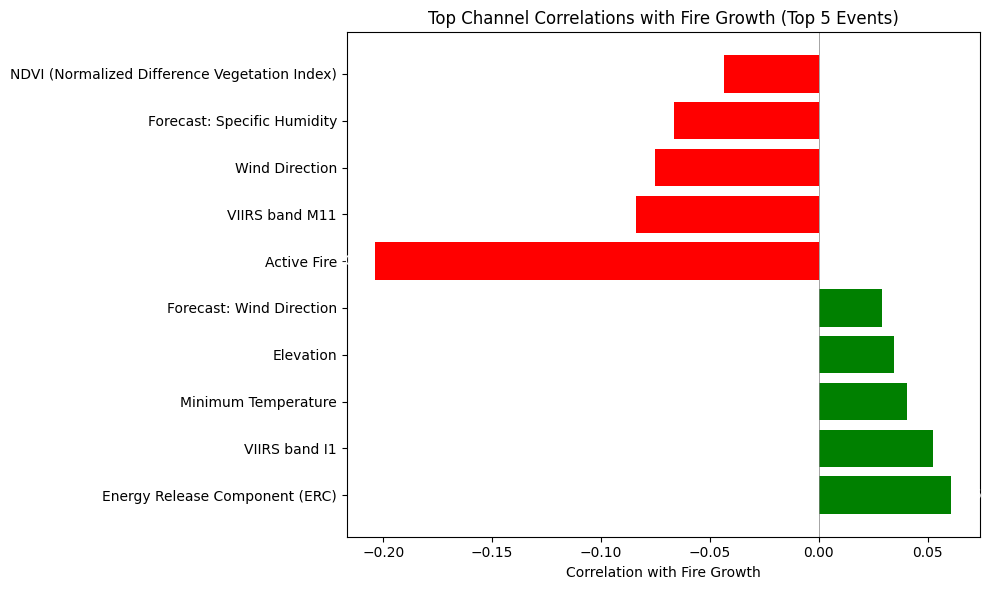

In [ ]:
# Function to visualize top channel correlations with fire growth using a bar chart
def visualize_top_channel_correlations(
    root_directory, events, fire_mask_channel=22, cmap='viridis', top_n=5
):
    correlations = {}

    for event in events:
        file_path = os.path.join(root_directory, event['year'], event['file_name'])
        print(f"Processing Event: File: {event['file_name']}, Year: {event['year']}, Time Step: {event['time_step']}")

        with h5py.File(file_path, 'r') as f:
            data = f['data']

            # Calculate fire growth as the difference between time steps
            before_fire = data[event['time_step'], fire_mask_channel, :, :]
            after_fire = data[event['time_step'] + 1, fire_mask_channel, :, :]
            fire_growth = (after_fire > 0).astype(int) - (before_fire > 0).astype(int)

            # Calculate correlation of each channel with fire growth
            for channel_index in range(data.shape[1]):
                channel_data = data[event['time_step'], channel_index, :, :].flatten()
                if not np.isnan(channel_data).any() and np.any(fire_growth):
                    correlation = np.corrcoef(channel_data, fire_growth.flatten())[0, 1]
                    channel_name = channel_labels[channel_index]

                    if channel_name not in correlations:
                        correlations[channel_name] = []

                    correlations[channel_name].append(correlation)

    # Aggregate correlations and sort by absolute values, ignoring NaNs
    avg_correlations = {k: np.nanmean(v) for k, v in correlations.items() if len(v) > 0}
    sorted_correlations = dict(sorted(avg_correlations.items(), key=lambda item: abs(item[1]), reverse=True))

    # Select top N positive and negative correlations
    top_positive = [(k, v) for k, v in sorted_correlations.items() if v > 0][:top_n]
    top_negative = [(k, v) for k, v in sorted_correlations.items() if v < 0][:top_n]

    # Combine top positive and negative correlations
    top_correlations = top_positive + top_negative

    if not top_correlations:
        print("No valid correlations found.")
        return

    # Create a bar plot for the top correlations
    plt.figure(figsize=(10, 6))
    colors = ['green' if val > 0 else 'red' for _, val in top_correlations]
    plt.barh([k for k, _ in top_correlations], [v for _, v in top_correlations], color=colors)
    plt.xlabel('Correlation with Fire Growth')
    plt.title('Top Channel Correlations with Fire Growth (Top 5 Events)')

    for index, (channel_name, value) in enumerate(top_correlations):
        plt.text(value, index, f"{value:.2f}", va='center', ha='left' if value > 0 else 'right', color='white')

    plt.axvline(0, color='grey', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Run the improved visualization for all 5 largest fire growth events
visualize_top_channel_correlations(
    root_directory,
    events=[
        {"year": '2021', "file_name": 'fire_25294714.hdf5', "time_step": 27},
        {"year": '2020', "file_name": 'fire_24332700.hdf5', "time_step": 9},
        {"year": '2020', "file_name": 'fire_24332628.hdf5', "time_step": 28},
        {"year": '2020', "file_name": 'fire_24332647.hdf5', "time_step": 28},
        {"year": '2020', "file_name": 'fire_24332628.hdf5', "time_step": 8}
    ]
)